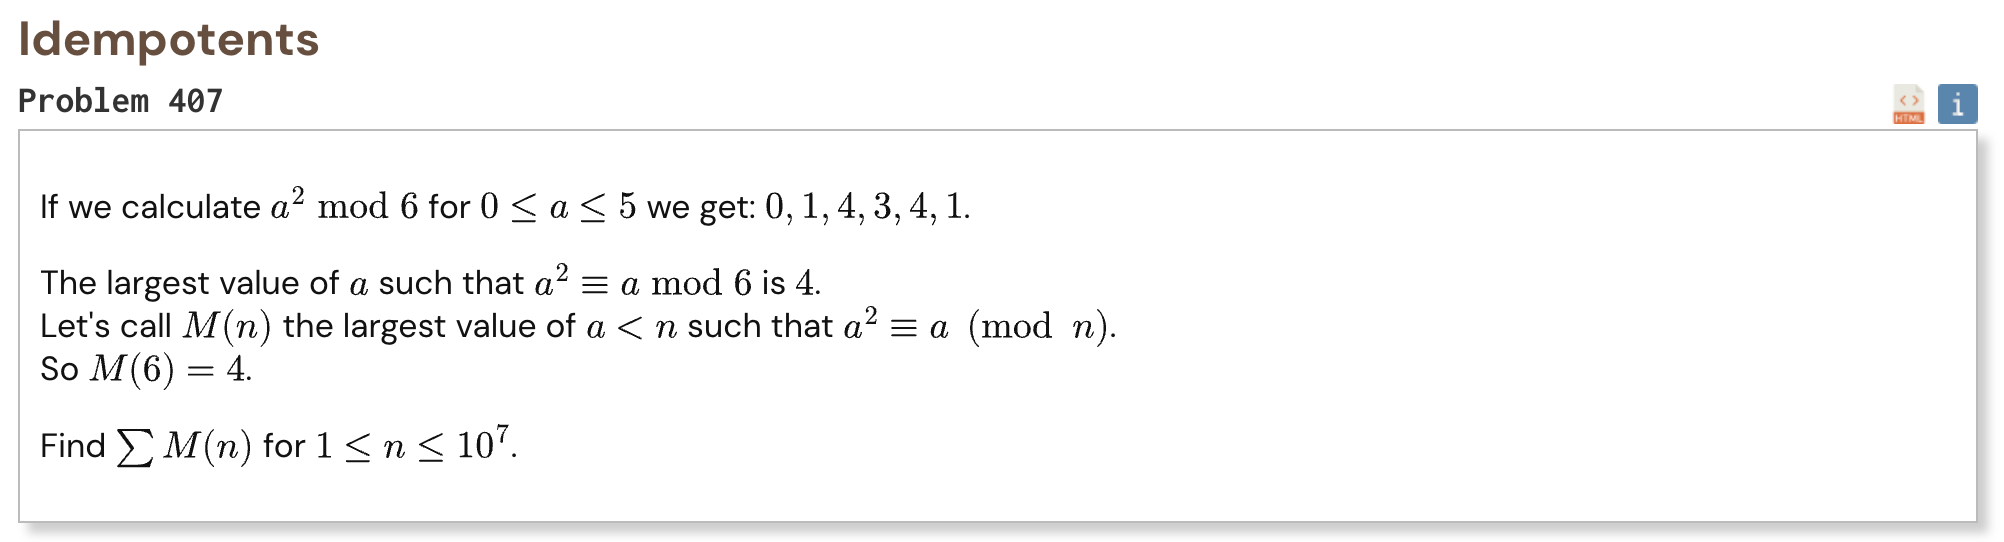

## Initial approach

-   the problem asks for numbers that behave like their own remainder when squared
-   these values are called idempotents because they satisfy a self-multiplication property
-   for each number, the largest valid value is related to the factorization of the number
-   use the chinese remainder theorem to construct the largest idempotent from prime factors
-   factor all numbers efficiently using a sieve
-   combine the prime power components to find the maximum idempotent value
-   sum all values and calculate the result modulo the given number

In [1]:
def sieve(n):
    spf = list(range(n + 1))
    for i in range(2, int(n ** 0.5) + 1):
        if spf[i] == i:
            for j in range(i * i, n + 1, i):
                if spf[j] == j:
                    spf[j] = i
    return spf


def factorize(x, spf):
    factors = []
    while x > 1:
        p = spf[x]
        power = 1
        while x % p == 0:
            x //= p
            power *= p
        factors.append(power)
    return factors


def egcd(a, b):
    if b == 0:
        return a, 1, 0
    g, x, y = egcd(b, a % b)
    return g, y, x - (a // b) * y


def crt(a, m, b, n):
    g, x, y = egcd(m, n)
    return (a + (b - a) * x * m // g) % (m * n)

In [2]:
%%time

limit = 10**7
MOD = 10**9

spf = sieve(limit)

result = 0

for n in range(2, limit + 1):
    factors = factorize(n, spf)

    if len(factors) == 1:
        continue

    value = 0
    mod = 1

    for p in factors:
        if value == 0:
            value = p
            mod = p
        else:
            value = crt(value, mod, 0, p)
            mod *= p

    other = n // mod
    value = max(value, crt(value, mod, 1, other) if other > 1 else value)

    result = (result + value) % MOD

print("Result:", result)

Result: 371857696
CPU times: user 33.7 s, sys: 130 ms, total: 33.8 s
Wall time: 33.8 s
